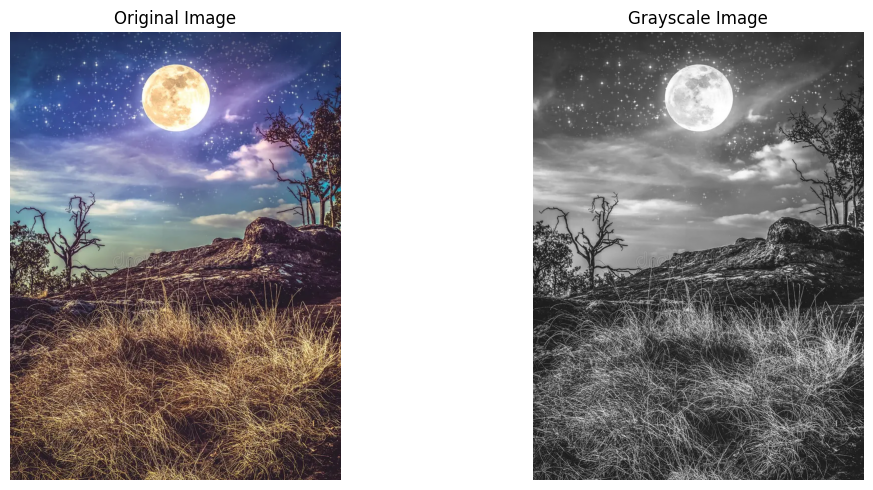

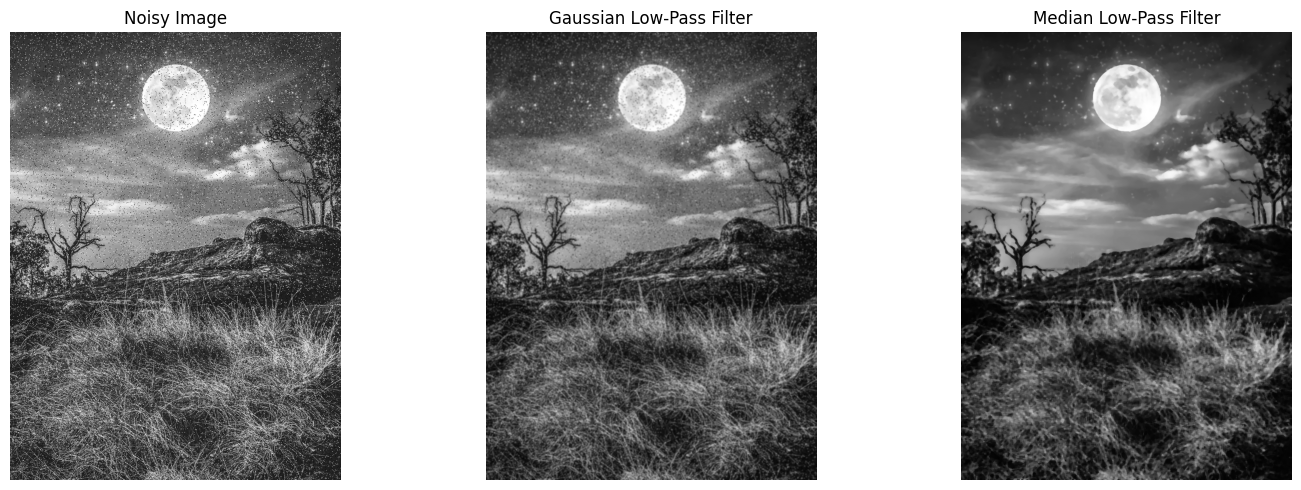

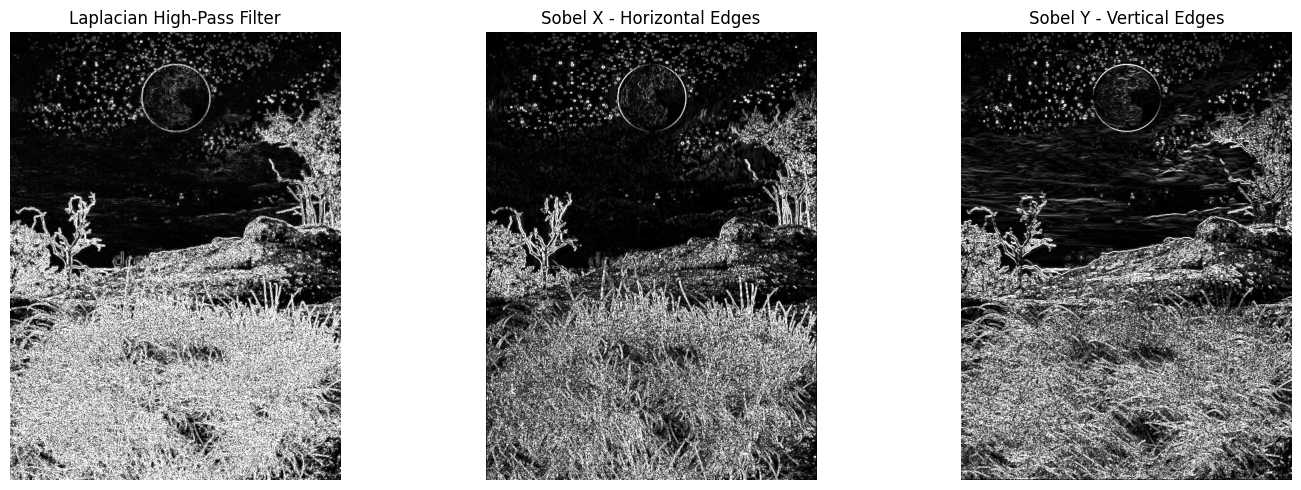

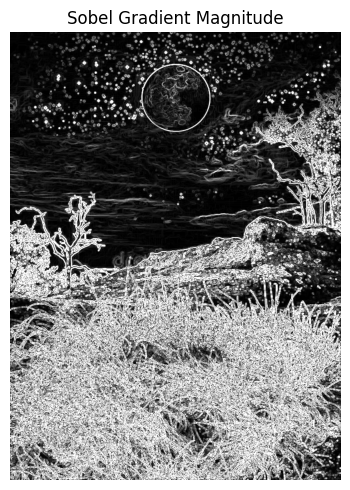

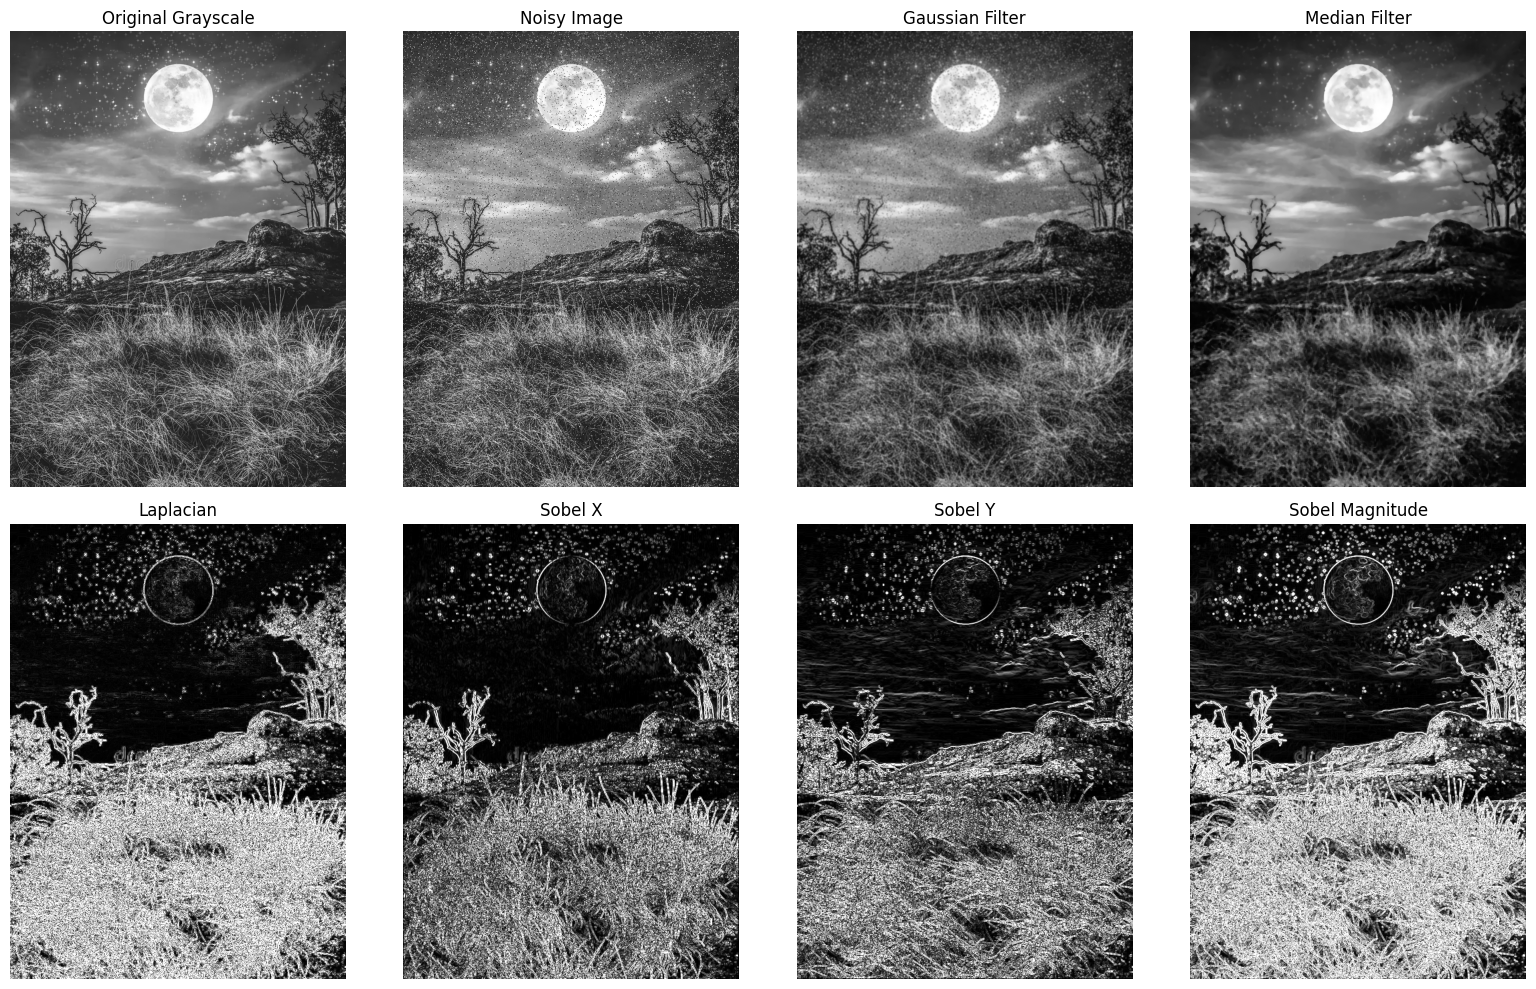


========== Computational Performance ==========
Gaussian Filter Time  : 0.001006 seconds
Median Filter Time    : 0.002176 seconds
Laplacian Time        : 0.004367 seconds
Sobel X Time          : 0.002523 seconds
Sobel Y Time          : 0.002652 seconds

========== Image Statistics ==========
Original Mean Intensity : 100.67
Noisy Mean Intensity    : 102.13
Gaussian Mean           : 102.14
Median Mean             : 97.87

========== Standard Deviation ==========
Original Std. Dev. : 53.56
Noisy Std. Dev.    : 60.68
Gaussian Std. Dev. : 44.49
Median Std. Dev.   : 47.70

========== Interpretation ==========

1. Gaussian filtering is a low-pass filtering technique.
   It smooths the image and reduces Gaussian-type noise,
   but can blur edges.

2. Median filtering is a nonlinear low-pass filter.
   It is particularly effective for salt-and-pepper noise
   while generally preserving edges better than Gaussian blur.

3. Laplacian filtering is a second-order derivative
   high-pass filter. I

In [5]:
# Experiment No. 3
import cv2
import numpy as np
import matplotlib.pyplot as plt
import timeit
# 1. Read the input image

image_path = "image.webp"   # Change this to your image filename

image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(
        f"Image not found: {image_path}. "
        "Please check the file path."
    )

# Convert BGR image to RGB for displaying with Matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# 2. Display original image and grayscale image

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.tight_layout()
plt.show()
# 3. Add salt-and-pepper noise

def add_salt_pepper_noise(img, amount=0.03):
    """
    Add salt-and-pepper noise to a grayscale image.

    amount:
        Fraction of pixels affected by noise.
    """

    noisy = img.copy()

    # Number of pixels to modify
    num_pixels = int(amount * img.size)

    # Salt noise (white pixels)
    coords = (
        np.random.randint(0, img.shape[0], num_pixels),
        np.random.randint(0, img.shape[1], num_pixels)
    )
    noisy[coords] = 255

    # Pepper noise (black pixels)
    coords = (
        np.random.randint(0, img.shape[0], num_pixels),
        np.random.randint(0, img.shape[1], num_pixels)
    )
    noisy[coords] = 0

    return noisy


noisy_image = add_salt_pepper_noise(gray, amount=0.03)
# 4. Apply Gaussian Blur (Low-Pass Filter)
start = time.perf_counter()

gaussian_filtered = cv2.GaussianBlur(
    noisy_image,
    (5, 5),
    0
)

gaussian_time = time.perf_counter() - start
# 5. Apply Median Filter (Low-Pass / Noise Removal)

start = time.perf_counter()

median_filtered = cv2.medianBlur(
    noisy_image,
    5
)

median_time = time.perf_counter() - start
# 6. Apply Laplacian Filter (High-Pass / Edge Detection)

# Laplacian requires a signed/float output because
# derivatives can contain negative values.

start = time.perf_counter()

laplacian = cv2.Laplacian(
    gray,
    cv2.CV_64F,
    ksize=3
)

laplacian_time = time.perf_counter() - start

# Convert to displayable 8-bit image
laplacian_display = cv2.convertScaleAbs(laplacian)
# 7. Apply Sobel filter in horizontal direction (X)

start = time.perf_counter()

sobel_x = cv2.Sobel(
    gray,
    cv2.CV_64F,
    dx=1,
    dy=0,
    ksize=3
)

sobel_x_time = time.perf_counter() - start

sobel_x_display = cv2.convertScaleAbs(sobel_x)
# 8. Apply Sobel filter in vertical direction (Y)

start = time.perf_counter()

sobel_y = cv2.Sobel(
    gray,
    cv2.CV_64F,
    dx=0,
    dy=1,
    ksize=3
)

sobel_y_time = time.perf_counter() - start

sobel_y_display = cv2.convertScaleAbs(sobel_y)
# 9. Calculate Sobel gradient magnitude

sobel_magnitude = cv2.magnitude(
    sobel_x.astype(np.float32),
    sobel_y.astype(np.float32)
)

sobel_magnitude = cv2.convertScaleAbs(sobel_magnitude)
# 10. Display Low-Pass Filter Results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(noisy_image, cmap="gray")
plt.title("Noisy Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gaussian_filtered, cmap="gray")
plt.title("Gaussian Low-Pass Filter")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(median_filtered, cmap="gray")
plt.title("Median Low-Pass Filter")
plt.axis("off")

plt.tight_layout()
plt.show()
# 11. Display High-Pass Filter / Edge Detection Results

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(laplacian_display, cmap="gray")
plt.title("Laplacian High-Pass Filter")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sobel_x_display, cmap="gray")
plt.title("Sobel X - Horizontal Edges")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sobel_y_display, cmap="gray")
plt.title("Sobel Y - Vertical Edges")
plt.axis("off")

plt.tight_layout()
plt.show()
# 12. Display Sobel Gradient Magnitude

plt.figure(figsize=(6, 5))

plt.imshow(sobel_magnitude, cmap="gray")
plt.title("Sobel Gradient Magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()
# 13. Compare all filtering techniques

plt.figure(figsize=(16, 10))

plt.subplot(2, 4, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(noisy_image, cmap="gray")
plt.title("Noisy Image")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(gaussian_filtered, cmap="gray")
plt.title("Gaussian Filter")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.imshow(median_filtered, cmap="gray")
plt.title("Median Filter")
plt.axis("off")

plt.subplot(2, 4, 5)
plt.imshow(laplacian_display, cmap="gray")
plt.title("Laplacian")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.imshow(sobel_x_display, cmap="gray")
plt.title("Sobel X")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.imshow(sobel_y_display, cmap="gray")
plt.title("Sobel Y")
plt.axis("off")

plt.subplot(2, 4, 8)
plt.imshow(sobel_magnitude, cmap="gray")
plt.title("Sobel Magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()
# 14. Print computational performance

print("\n========== Computational Performance ==========")

print(f"Gaussian Filter Time  : {gaussian_time:.6f} seconds")
print(f"Median Filter Time    : {median_time:.6f} seconds")
print(f"Laplacian Time        : {laplacian_time:.6f} seconds")
print(f"Sobel X Time          : {sobel_x_time:.6f} seconds")
print(f"Sobel Y Time          : {sobel_y_time:.6f} seconds")
# 15. Basic statistical comparison


print("\n========== Image Statistics ==========")

print(f"Original Mean Intensity : {np.mean(gray):.2f}")
print(f"Noisy Mean Intensity    : {np.mean(noisy_image):.2f}")
print(f"Gaussian Mean           : {np.mean(gaussian_filtered):.2f}")
print(f"Median Mean             : {np.mean(median_filtered):.2f}")

print("\n========== Standard Deviation ==========")

print(f"Original Std. Dev. : {np.std(gray):.2f}")
print(f"Noisy Std. Dev.    : {np.std(noisy_image):.2f}")
print(f"Gaussian Std. Dev. : {np.std(gaussian_filtered):.2f}")
print(f"Median Std. Dev.   : {np.std(median_filtered):.2f}")
# 16. Interpretation
print("\n========== Interpretation ==========")

print("""
1. Gaussian filtering is a low-pass filtering technique.
   It smooths the image and reduces Gaussian-type noise,
   but can blur edges.

2. Median filtering is a nonlinear low-pass filter.
   It is particularly effective for salt-and-pepper noise
   while generally preserving edges better than Gaussian blur.

3. Laplacian filtering is a second-order derivative
   high-pass filter. It emphasizes rapid intensity changes
   and therefore detects edges.

4. Sobel X detects intensity changes mainly in the
   horizontal-gradient direction and highlights vertical edges.

5. Sobel Y detects intensity changes mainly in the
   vertical-gradient direction and highlights horizontal edges.

6. Sobel gradient magnitude combines the X and Y gradients
   to produce an overall edge-strength image.
""")